# Классификация изображений кожных поражений

## Итоговая аттестационная работа по профессии «Data Science в медицине»

**Задача:** построить end-to-end pipeline для классификации фотографий кожных поражений по размеченным заболеваниям.

**Важно:** модель из этой работы не является медицинским диагностическим инструментом. Корректный сценарий применения — система поддержки принятия решений врача, где неуверенные случаи отправляются на обязательную экспертную проверку.

## Где запускать ноутбук с датасетом 12 ГБ без интернета

Датасет такого размера **не нужно загружать в GitHub**. Оптимальный сценарий для этой работы — **Kaggle Notebook + private Kaggle Dataset**.

Если ваш тариф Kaggle **не позволяет включить Internet**, это не блокер. Нужно загрузить не только датасет с изображениями, но и два файла предобученных весов `torchvision` как отдельный private Kaggle Dataset:

- `resnet18-f37072fd.pth` для `ResNet18`;
- `mobilenet_v3_large-8738ca79.pth` для `MobileNetV3-Large`.

Порядок действий:

1. Скачайте архив датасета с Cloud Mail на свой компьютер.
2. Создайте на Kaggle приватный Dataset с изображениями, например `projectskill-skin-lesions`.
3. Создайте второй приватный Dataset с весами, например `torchvision-imagenet-weights`, и загрузите туда два `.pth`-файла.
4. Создайте Kaggle Notebook, нажмите **Add data** и подключите оба Dataset: изображения и веса.
5. Включите GPU в настройках ноутбука: **Settings → Accelerator → GPU**.
6. Оставьте **Internet выключенным**. Ноутбук по умолчанию использует `PRETRAINED_WEIGHTS_MODE = "local"` и ищет веса в `/kaggle/input`.
7. Загрузите этот `.ipynb` в Kaggle и запускайте сверху вниз.

Почему Kaggle выбран как основной вариант: данные лежат отдельно от кода, GitHub не засоряется 12 ГБ файлами, GPU доступен в браузере, а путь к данным обычно выглядит как `/kaggle/input/<dataset-name>/...`.

Для первого быстрого прогона можно поставить переменную окружения `SAMPLE_PER_CLASS=200` или изменить параметр `SAMPLE_PER_CLASS` ниже. Для финальной сдачи лучше вернуть `SAMPLE_PER_CLASS = 0`, чтобы использовать все доступные изображения, если хватает времени и GPU.


## 1. Импорты и настройки воспроизводимости

В этом разделе подключаются библиотеки, задаются random seeds и основные параметры эксперимента. Если `albumentations` или `pytorch-grad-cam` недоступны, ноутбук содержит fallback-варианты на `torchvision` и визуальный анализ ошибок.

In [1]:
from __future__ import annotations

import copy
import importlib.util
import json
import math
import os
import random
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from PIL import Image, ImageFile, UnidentifiedImageError
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

ALBUMENTATIONS_AVAILABLE = importlib.util.find_spec("albumentations") is not None
if ALBUMENTATIONS_AVAILABLE:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = int(os.getenv("BATCH_SIZE", "32"))
NUM_WORKERS = int(os.getenv("NUM_WORKERS", "2"))
SAMPLE_PER_CLASS = int(os.getenv("SAMPLE_PER_CLASS", "0"))
PRETRAINED_WEIGHTS_MODE = os.getenv("PRETRAINED_WEIGHTS_MODE", "local").lower()
LOCAL_WEIGHTS_DIR = os.getenv("LOCAL_WEIGHTS_DIR")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)
print(f"Device: {DEVICE}")
print(f"Torch: {torch.__version__}, Torchvision: {torchvision.__version__}")
print(f"Albumentations available: {ALBUMENTATIONS_AVAILABLE}")
print(f"Batch size: {BATCH_SIZE}, sample per class: {SAMPLE_PER_CLASS}")


Device: cpu
Torch: 2.10.0+cpu, Torchvision: 0.25.0+cpu
Albumentations available: True
Batch size: 32, sample per class: 0


/usr/local/lib/python3.12/dist-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


## 2. Загрузка данных и определение структуры

Поддерживаются два типовых формата датасета:

1. **Классы заданы папками:** `dataset/class_name/image.jpg`.
2. **Есть metadata.csv:** изображения лежат отдельно, а метки находятся в таблице.

Перед запуском укажите правильный путь в `DATA_DIR`. Если у вас есть `metadata.csv`, заполните имена колонок `IMAGE_ID_COLUMN` и `LABEL_COLUMN`.

In [2]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def iter_image_paths(root: Path):
    if not root.exists():
        return
    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            yield path


def find_images(root: Path) -> list[Path]:
    return sorted(iter_image_paths(root))


def has_images(root: Path) -> bool:
    return next(iter_image_paths(root), None) is not None


def detect_data_dir() -> Path:
    """Find a reasonable dataset directory for local, Kaggle or Colab runs."""
    candidates: list[Path] = []

    env_data_dir = os.getenv("DATA_DIR")
    if env_data_dir:
        candidates.append(Path(env_data_dir))

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        candidates.extend(path for path in kaggle_input.iterdir() if path.is_dir())
        candidates.append(kaggle_input)

    candidates.extend(
        [
            Path("/content/drive/MyDrive/ProjectSkill/data"),
            Path("/content/data"),
            Path("../data"),
            Path("data"),
        ]
    )

    for candidate in candidates:
        if candidate.exists() and has_images(candidate):
            return candidate
    return Path(os.getenv("DATA_DIR", "../data"))


DATA_DIR = detect_data_dir()
OUTPUT_DIR = Path(os.getenv("OUTPUT_DIR", "/kaggle/working/outputs" if Path("/kaggle").exists() else "../outputs"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Если метки находятся в CSV, укажите путь к metadata.csv и названия колонок.
METADATA_PATH = None  # пример: DATA_DIR / "metadata.csv"
IMAGE_ID_COLUMN = "image_id"
LABEL_COLUMN = "label"
IMAGE_ROOT = DATA_DIR

print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print("Первые найденные изображения:")
for path in find_images(DATA_DIR)[:5]:
    print(" -", path)


def build_dataframe_from_folders(root: Path) -> pd.DataFrame:
    image_paths = find_images(root)
    records = []
    for path in image_paths:
        label = path.parent.name
        records.append({"image_path": str(path), "label": label})
    return pd.DataFrame(records)


def build_dataframe_from_metadata(
    metadata_path: Path,
    image_root: Path,
    image_id_column: str,
    label_column: str,
) -> pd.DataFrame:
    metadata = pd.read_csv(metadata_path)
    image_paths = find_images(image_root)
    image_lookup = {path.stem: path for path in image_paths}
    image_lookup.update({path.name: path for path in image_paths})
    records = []
    for _, row in metadata.iterrows():
        image_id = str(row[image_id_column])
        image_path = image_lookup.get(image_id) or image_lookup.get(Path(image_id).stem)
        if image_path is not None:
            records.append({"image_path": str(image_path), "label": row[label_column]})
    return pd.DataFrame(records)


if METADATA_PATH is not None:
    df = build_dataframe_from_metadata(
        METADATA_PATH,
        IMAGE_ROOT,
        IMAGE_ID_COLUMN,
        LABEL_COLUMN,
    )
else:
    df = build_dataframe_from_folders(DATA_DIR)

if SAMPLE_PER_CLASS > 0 and len(df) > 0:
    df = (
        df.groupby("label", group_keys=False)
        .apply(lambda group: group.sample(min(len(group), SAMPLE_PER_CLASS), random_state=SEED))
        .reset_index(drop=True)
    )
    print(f"Включён быстрый режим: максимум {SAMPLE_PER_CLASS} изображений на класс.")

print(f"Всего найдено изображений: {len(df)}")
df.head()

DATA_DIR: /kaggle/input/datasets
OUTPUT_DIR: /kaggle/working/outputs
Первые найденные изображения:
 - /kaggle/input/datasets/drmatt91/projectskill-skin-lesions/test/img/ISIC_0012266.jpg
 - /kaggle/input/datasets/drmatt91/projectskill-skin-lesions/test/img/ISIC_0012273.jpg
 - /kaggle/input/datasets/drmatt91/projectskill-skin-lesions/test/img/ISIC_0012757.jpg
 - /kaggle/input/datasets/drmatt91/projectskill-skin-lesions/test/img/ISIC_0013109.jpg
 - /kaggle/input/datasets/drmatt91/projectskill-skin-lesions/test/img/ISIC_0013203.jpg
Всего найдено изображений: 112


,image_path,label
0,/kaggle/input/datasets/drmatt91/projectskill-s...,img
1,/kaggle/input/datasets/drmatt91/projectskill-s...,img
2,/kaggle/input/datasets/drmatt91/projectskill-s...,img
3,/kaggle/input/datasets/drmatt91/projectskill-s...,img
4,/kaggle/input/datasets/drmatt91/projectskill-s...,img


## 3. Проверка и очистка изображений

Проверяем читаемость файлов, формат, размеры, число каналов, яркость, размер файла и дубликаты путей. Битые изображения исключаются из дальнейшей работы.

In [3]:
def inspect_image(path: str) -> dict:
    result = {
        "image_path": path,
        "is_valid": False,
        "width": np.nan,
        "height": np.nan,
        "channels": np.nan,
        "image_format": None,
        "file_size": np.nan,
        "aspect_ratio": np.nan,
        "mean_brightness": np.nan,
    }
    try:
        file_path = Path(path)
        with Image.open(file_path) as image:
            image_format = image.format
            image = image.convert("RGB")
            array = np.asarray(image)
            height, width, channels = array.shape
            result.update(
                {
                    "is_valid": True,
                    "width": width,
                    "height": height,
                    "channels": channels,
                    "image_format": image_format,
                    "file_size": file_path.stat().st_size,
                    "aspect_ratio": width / height,
                    "mean_brightness": float(array.mean()),
                }
            )
    except (FileNotFoundError, UnidentifiedImageError, OSError, ValueError):
        pass
    return result

if len(df) == 0:
    raise ValueError(
        "Датасет не найден. Проверьте DATA_DIR, METADATA_PATH и структуру папок."
    )

image_info = pd.DataFrame([inspect_image(path) for path in df["image_path"]])
df = df.merge(image_info, on="image_path", how="left")

invalid_count = int((~df["is_valid"]).sum())
df = df[df["is_valid"]].drop_duplicates(subset="image_path").reset_index(drop=True)

class_names = sorted(df["label"].astype(str).unique())
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}
df["label"] = df["label"].astype(str)
df["label_id"] = df["label"].map(class_to_idx)

print(f"Битых/непрочитанных изображений исключено: {invalid_count}")
print(f"Изображений после очистки: {len(df)}")
print(f"Классов: {len(class_names)}")
print(class_to_idx)
df.head()

Битых/непрочитанных изображений исключено: 0
Изображений после очистки: 112
Классов: 1
{'img': 0}


,image_path,label,is_valid,width,height,channels,image_format,file_size,aspect_ratio,mean_brightness,label_id
0,/kaggle/input/datasets/drmatt91/projectskill-s...,img,True,4288,2848,3,JPEG,4565936,1.505618,146.563683,0
1,/kaggle/input/datasets/drmatt91/projectskill-s...,img,True,3008,2000,3,JPEG,2733516,1.504000,105.714819,0
2,/kaggle/input/datasets/drmatt91/projectskill-s...,img,True,3872,2592,3,JPEG,3689672,1.493827,156.589902,0
3,/kaggle/input/datasets/drmatt91/projectskill-s...,img,True,3008,2000,3,JPEG,3131375,1.504000,148.497520,0
4,/kaggle/input/datasets/drmatt91/projectskill-s...,img,True,3008,2000,3,JPEG,2637146,1.504000,159.619381,0


### Вывод по проверке данных

Заполните после запуска:

- Всего валидных изображений: `...`.
- Исключено битых файлов: `...`.
- Все изображения приводятся к RGB-формату, что обеспечивает единый вход модели.
- Основное ограничение: если в данных нет `patient_id`, невозможно гарантировать patient-level split; это нужно указать как риск утечки похожих изображений между выборками.

## 4. EDA: распределение классов, примеры и статистики изображений

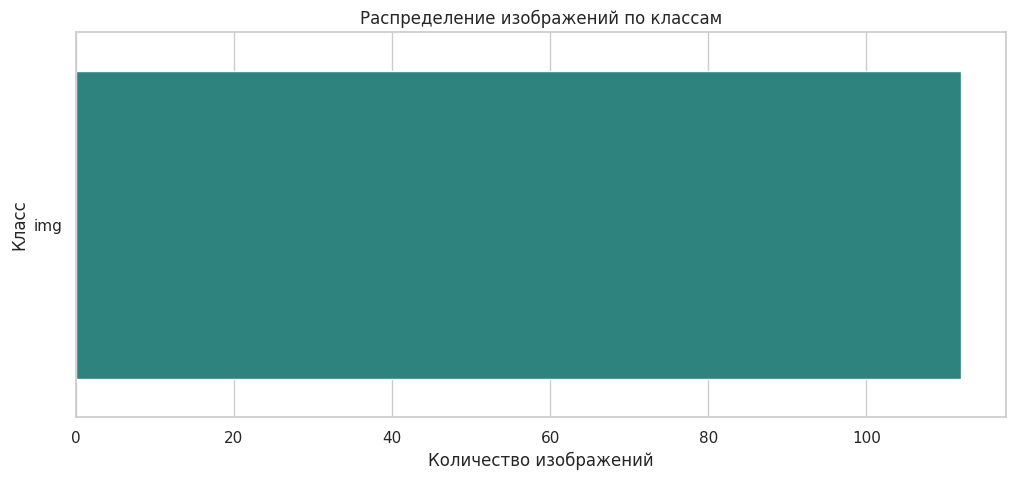

label
img    112
Name: count, dtype: int64
Доля самого частого класса: 100.00%
Доля самого редкого класса: 100.00%


In [4]:
def plot_class_distribution(data: pd.DataFrame) -> None:
    plt.figure(figsize=(12, 5))
    order = data["label"].value_counts().index
    sns.countplot(data=data, y="label", order=order, palette="viridis")
    plt.title("Распределение изображений по классам")
    plt.xlabel("Количество изображений")
    plt.ylabel("Класс")
    plt.show()

plot_class_distribution(df)
class_distribution = df["label"].value_counts()
print(class_distribution)
print(f"Доля самого частого класса: {class_distribution.max() / len(df):.2%}")
print(f"Доля самого редкого класса: {class_distribution.min() / len(df):.2%}")

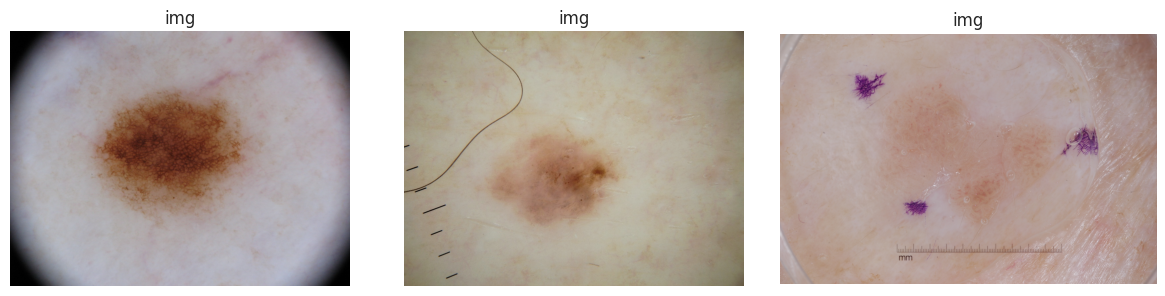

In [5]:
def show_class_examples(
    data: pd.DataFrame,
    images_per_class: int = 3,
    max_classes: int = 10,
) -> None:
    selected_classes = data["label"].value_counts().head(max_classes).index
    fig, axes = plt.subplots(
        len(selected_classes),
        images_per_class,
        figsize=(4 * images_per_class, 3 * len(selected_classes)),
    )
    if len(selected_classes) == 1:
        axes = np.expand_dims(axes, axis=0)
    for row_idx, label in enumerate(selected_classes):
        sample = data[data["label"] == label].sample(
            min(images_per_class, (data["label"] == label).sum()),
            random_state=SEED,
        )
        for col_idx in range(images_per_class):
            ax = axes[row_idx, col_idx]
            ax.axis("off")
            if col_idx < len(sample):
                image = Image.open(sample.iloc[col_idx]["image_path"]).convert("RGB")
                ax.imshow(image)
                ax.set_title(label)
    plt.tight_layout()
    plt.show()

show_class_examples(df, images_per_class=3, max_classes=min(8, len(class_names)))

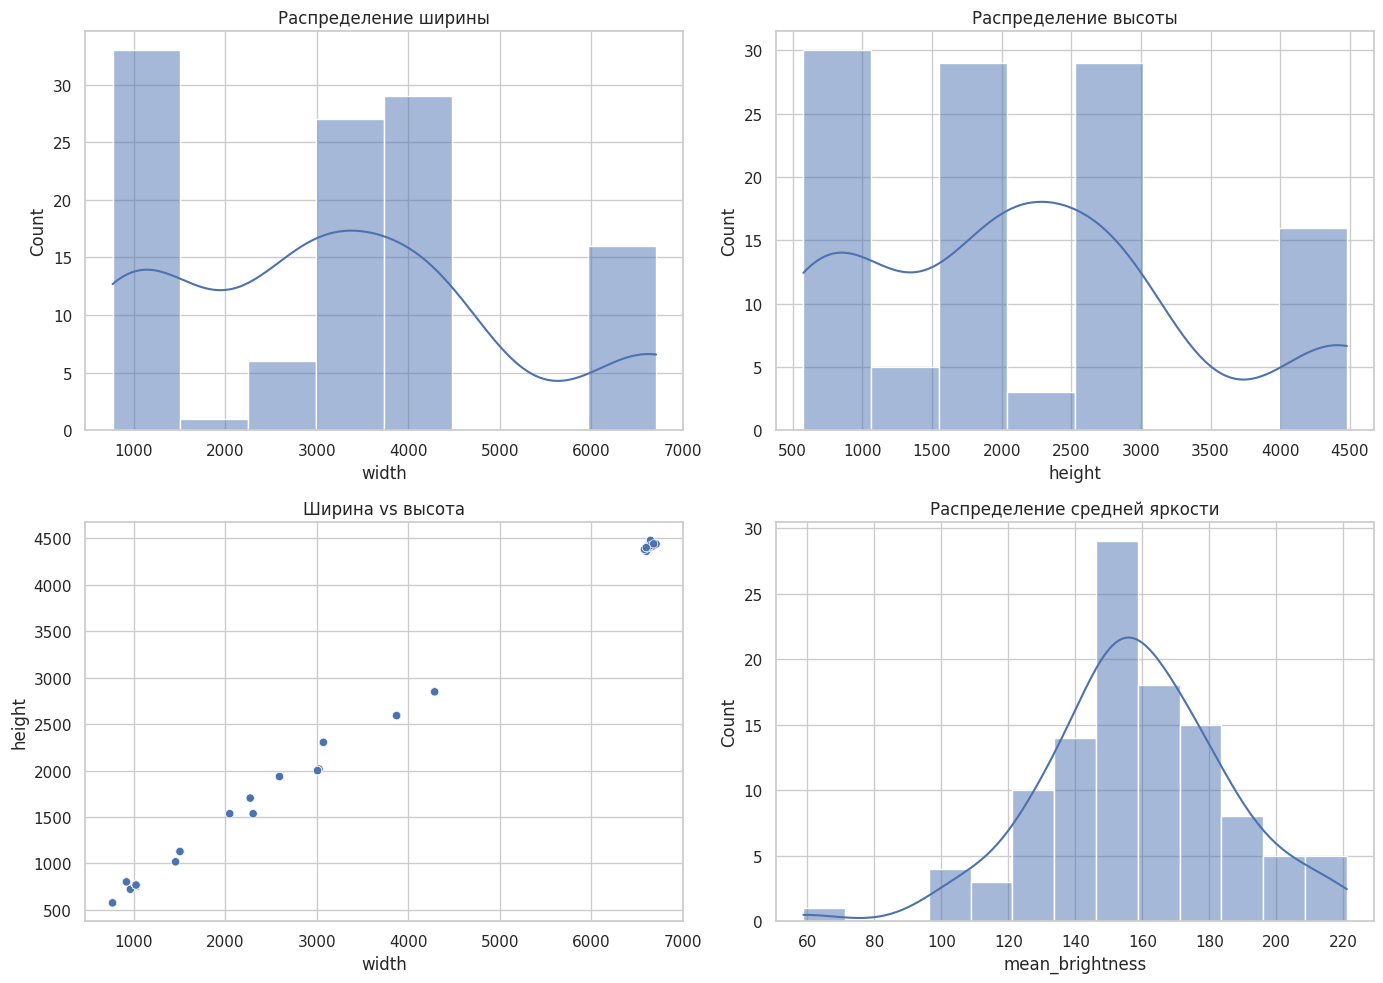

,width,height,aspect_ratio,mean_brightness,file_size
count,112.000000,112.000000,112.000000,112.000000,1.120000e+02
mean,3218.839286,2186.910714,1.435747,157.746185,4.243618e+06
std,1854.560935,1196.832965,0.093256,27.359935,5.483098e+06
min,767.000000,576.000000,1.145885,58.824983,4.286100e+04
25%,1027.000000,802.000000,1.333333,143.398914,3.249542e+05
50%,3008.000000,2000.000000,1.500913,156.528568,2.652512e+06
75%,4288.000000,2848.000000,1.505154,173.852356,4.575592e+06
max,6708.000000,4479.000000,1.513873,221.003587,2.087940e+07


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df["width"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Распределение ширины")
sns.histplot(df["height"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Распределение высоты")
sns.scatterplot(data=df, x="width", y="height", hue="label", ax=axes[1, 0], legend=False)
axes[1, 0].set_title("Ширина vs высота")
sns.histplot(df["mean_brightness"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Распределение средней яркости")
plt.tight_layout()
plt.show()

df[["width", "height", "aspect_ratio", "mean_brightness", "file_size"]].describe()

### Выводы по EDA

Заполните после построения графиков:

- В датасете `...` классов и `...` валидных изображений.
- Есть/нет выраженный дисбаланс классов. Если дисбаланс есть, далее используются stratified split, macro F1, balanced accuracy и class weights.
- Изображения различаются по размеру, яркости и масштабу, поэтому применяется resize до 224×224 и умеренные аугментации.
- Визуально классы могут быть похожи, поэтому важно анализировать confusion matrix и ошибки модели.

## 5. Предобработка и аугментации

Для моделей с ImageNet-весами применяется нормализация ImageNet. Случайные аугментации используются только для train-выборки; validation/test получают только детерминированные преобразования.

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

if ALBUMENTATIONS_AVAILABLE:
    train_transform = A.Compose(
        [
            A.Resize(IMAGE_SIZE, IMAGE_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.ShiftScaleRotate(
                shift_limit=0.05,
                scale_limit=0.10,
                rotate_limit=20,
                p=0.5,
            ),
            A.RandomBrightnessContrast(
                brightness_limit=0.15,
                contrast_limit=0.15,
                p=0.4,
            ),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ]
    )
    valid_transform = A.Compose(
        [
            A.Resize(IMAGE_SIZE, IMAGE_SIZE),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ]
    )
else:
    train_transform = transforms.Compose(
        [
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(degrees=20),
            transforms.ColorJitter(brightness=0.15, contrast=0.15),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ]
    )
    valid_transform = transforms.Compose(
        [
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ]
    )

def denormalize_tensor(tensor: torch.Tensor) -> np.ndarray:
    image = tensor.detach().cpu().permute(1, 2, 0).numpy()
    image = image * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(image, 0, 1)

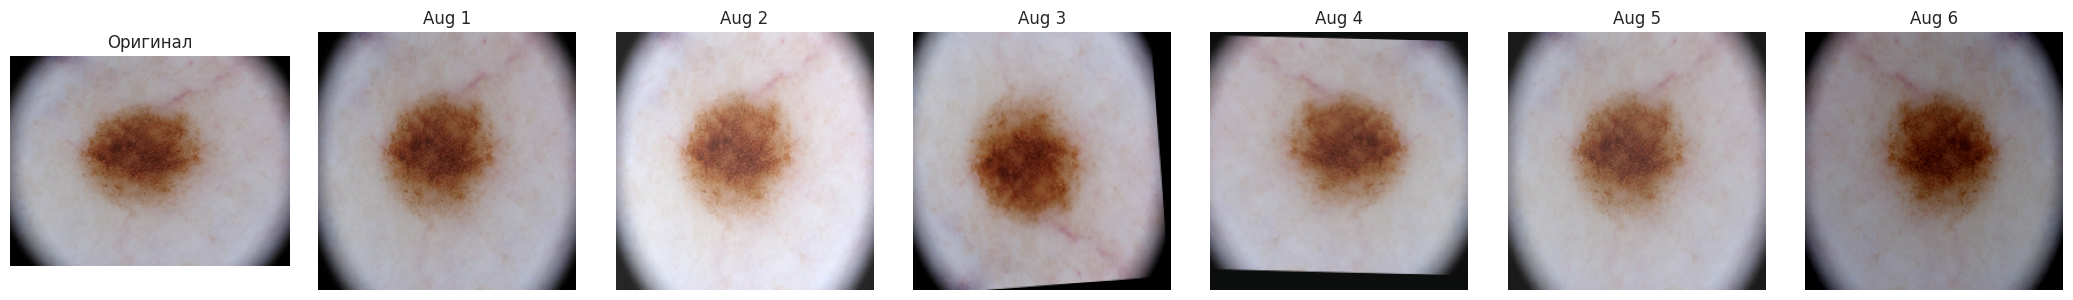

In [8]:
def apply_transform(image: Image.Image, transform: Callable) -> torch.Tensor:
    if ALBUMENTATIONS_AVAILABLE:
        transformed = transform(image=np.asarray(image))
        return transformed["image"]
    return transform(image)

def show_augmentations(data: pd.DataFrame, n_augmented: int = 6) -> None:
    sample_path = data.sample(1, random_state=SEED).iloc[0]["image_path"]
    image = Image.open(sample_path).convert("RGB")
    fig, axes = plt.subplots(1, n_augmented + 1, figsize=(3 * (n_augmented + 1), 3))
    axes[0].imshow(image)
    axes[0].set_title("Оригинал")
    axes[0].axis("off")
    for idx in range(n_augmented):
        transformed = apply_transform(image, train_transform)
        axes[idx + 1].imshow(denormalize_tensor(transformed))
        axes[idx + 1].set_title(f"Aug {idx + 1}")
        axes[idx + 1].axis("off")
    plt.tight_layout()
    plt.show()

show_augmentations(df)

## 6. Train/validation/test split

Используется стратификация по `label_id`: 70% train, 15% validation, 15% test. Если в данных есть `patient_id`, замените этот блок на patient-level split.

In [9]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label_id"],
    random_state=SEED,
)
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_id"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(train_df.shape, valid_df.shape, test_df.shape)
print("Train distribution:")
print(train_df["label"].value_counts(normalize=True).round(3))

(78, 11) (17, 11) (17, 11)
Train distribution:
label
img    1.0
Name: proportion, dtype: float64


## 7. Dataset и DataLoader

In [10]:
class SkinLesionDataset(Dataset):
    def __init__(self, data: pd.DataFrame, transform: Callable | None = None) -> None:
        self.data = data.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        row = self.data.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label_id"])
        if self.transform is not None:
            image = apply_transform(image, self.transform)
        return image, label

def create_class_weights(data: pd.DataFrame) -> torch.Tensor:
    counts = data["label_id"].value_counts().sort_index().values
    weights = counts.sum() / (len(counts) * counts)
    return torch.tensor(weights, dtype=torch.float32)

class_weights = create_class_weights(train_df).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

train_dataset = SkinLesionDataset(train_df, transform=train_transform)
valid_dataset = SkinLesionDataset(valid_df, transform=valid_transform)
test_dataset = SkinLesionDataset(test_df, transform=valid_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

## 8. Модели: ResNet18 и MobileNetV3

Для экономии ресурсов используются компактные модели с предобученными ImageNet-весами. Если GPU позволяет, MobileNetV3 можно заменить на EfficientNet-B0 или ResNet50.

Ноутбук рассчитан на запуск **без интернет-доступа**: по умолчанию `PRETRAINED_WEIGHTS_MODE = "local"`. В этом режиме он не пытается скачивать веса, а ищет заранее загруженные файлы `resnet18-f37072fd.pth` и `mobilenet_v3_large-8738ca79.pth` в `LOCAL_WEIGHTS_DIR`, `weights/`, `../weights/` и `/kaggle/input`. Если веса не найдены, ячейка остановится с понятной ошибкой, чтобы случайно не потерять баллы за pretrained-модель.

Если вы запускаете ноутбук в среде, где интернет разрешён, можно поставить `PRETRAINED_WEIGHTS_MODE = "download"`; тогда `torchvision` скачает веса автоматически. Если нужно обучать модели полностью с нуля, поставьте `PRETRAINED_WEIGHTS_MODE = "none"`, но это хуже для критерия моделирования.


In [11]:
TORCHVISION_WEIGHT_FILES = {
    "resnet18": "resnet18-f37072fd.pth",
    "mobilenet_v3_large": "mobilenet_v3_large-8738ca79.pth",
}

TORCHVISION_WEIGHT_URLS = {
    "resnet18": "https://download.pytorch.org/models/resnet18-f37072fd.pth",
    "mobilenet_v3_large": "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth",
}


def get_weight_search_dirs() -> list[Path]:
    """Return directories where offline pretrained weights may be stored."""
    candidates: list[Path] = []
    if LOCAL_WEIGHTS_DIR:
        candidates.append(Path(LOCAL_WEIGHTS_DIR))
    candidates.extend(
        [
            Path("/kaggle/input/torchvision-imagenet-weights"),
            Path("/kaggle/input"),
            Path("/content/drive/MyDrive/ProjectSkill/weights"),
            Path("../weights"),
            Path("weights"),
        ]
    )
    return [path for path in candidates if path.exists()]


def find_local_weight_file(model_name: str) -> Path | None:
    """Find a local torchvision .pth file for a pretrained model."""
    file_name = TORCHVISION_WEIGHT_FILES[model_name]
    for directory in get_weight_search_dirs():
        direct_path = directory / file_name
        if direct_path.exists():
            return direct_path
        matches = list(directory.rglob(file_name))
        if matches:
            return matches[0]
    return None


def load_local_state_dict(model: nn.Module, model_name: str) -> None:
    """Load ImageNet weights from a local .pth file without internet access."""
    weight_path = find_local_weight_file(model_name)
    if weight_path is None:
        search_dirs = ", ".join(str(path) for path in get_weight_search_dirs())
        expected_file = TORCHVISION_WEIGHT_FILES[model_name]
        download_url = TORCHVISION_WEIGHT_URLS[model_name]
        raise FileNotFoundError(
            f"Не найден файл предобученных весов {expected_file}. "
            f"Скачайте его заранее: {download_url}. "
            f"Загрузите файл в Kaggle Dataset с весами или укажите LOCAL_WEIGHTS_DIR. "
            f"Проверенные папки: {search_dirs or 'нет существующих папок'}."
        )
    state_dict = torch.load(weight_path, map_location="cpu")
    if isinstance(state_dict, dict) and "state_dict" in state_dict:
        state_dict = state_dict["state_dict"]
    model.load_state_dict(state_dict)
    print(f"Loaded pretrained weights for {model_name}: {weight_path}")


def create_resnet18(num_classes: int, pretrained: bool = True) -> nn.Module:
    if pretrained and PRETRAINED_WEIGHTS_MODE == "download":
        weights = models.ResNet18_Weights.IMAGENET1K_V1
        model = models.resnet18(weights=weights)
    else:
        model = models.resnet18(weights=None)
        if pretrained and PRETRAINED_WEIGHTS_MODE == "local":
            load_local_state_dict(model, "resnet18")
        elif pretrained and PRETRAINED_WEIGHTS_MODE != "none":
            raise ValueError(
                "PRETRAINED_WEIGHTS_MODE должен быть 'local', 'download' или 'none'."
            )
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def create_mobilenet_v3(num_classes: int, pretrained: bool = True) -> nn.Module:
    if pretrained and PRETRAINED_WEIGHTS_MODE == "download":
        weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
        model = models.mobilenet_v3_large(weights=weights)
    else:
        model = models.mobilenet_v3_large(weights=None)
        if pretrained and PRETRAINED_WEIGHTS_MODE == "local":
            load_local_state_dict(model, "mobilenet_v3_large")
        elif pretrained and PRETRAINED_WEIGHTS_MODE != "none":
            raise ValueError(
                "PRETRAINED_WEIGHTS_MODE должен быть 'local', 'download' или 'none'."
            )
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def set_backbone_trainable(model: nn.Module, trainable: bool) -> None:
    for param in model.parameters():
        param.requires_grad = trainable


def train_classifier_head(model: nn.Module) -> None:
    set_backbone_trainable(model, False)
    if hasattr(model, "fc"):
        for param in model.fc.parameters():
            param.requires_grad = True
    if hasattr(model, "classifier"):
        for param in model.classifier.parameters():
            param.requires_grad = True


## 9. Цикл обучения и оценка по эпохам

In [12]:
@dataclass
class ExperimentConfig:
    model_name: str
    learning_rate: float
    batch_size: int
    epochs: int
    fine_tuning: bool
    weight_decay: float = 1e-4


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion_fn: nn.Module,
    optimizer: optim.Optimizer | None = None,
) -> dict:
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    losses, predictions, targets = [], [], []

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion_fn(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        losses.append(loss.item())
        predictions.extend(logits.argmax(dim=1).detach().cpu().numpy())
        targets.extend(labels.detach().cpu().numpy())

    return {
        "loss": float(np.mean(losses)),
        "accuracy": accuracy_score(targets, predictions),
        "macro_f1": f1_score(targets, predictions, average="macro", zero_division=0),
    }


def fit_model(
    model: nn.Module,
    train_loader: DataLoader,
    valid_loader: DataLoader,
    config: ExperimentConfig,
    criterion_fn: nn.Module,
) -> tuple[nn.Module, pd.DataFrame]:
    model = model.to(DEVICE)
    optimizer = optim.AdamW(
        filter(lambda parameter: parameter.requires_grad, model.parameters()),
        lr=config.learning_rate,
        weight_decay=config.weight_decay,
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
    )
    best_model_state = copy.deepcopy(model.state_dict())
    best_macro_f1 = -math.inf
    history = []

    for epoch in range(1, config.epochs + 1):
        start_time = time.time()
        train_metrics = run_epoch(model, train_loader, criterion_fn, optimizer)
        valid_metrics = run_epoch(model, valid_loader, criterion_fn)
        scheduler.step(valid_metrics["loss"])

        row = {
            "epoch": epoch,
            "model": config.model_name,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": train_metrics["loss"],
            "valid_loss": valid_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "valid_accuracy": valid_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "valid_macro_f1": valid_metrics["macro_f1"],
            "seconds": time.time() - start_time,
        }
        history.append(row)
        print(row)

        if valid_metrics["macro_f1"] > best_macro_f1:
            best_macro_f1 = valid_metrics["macro_f1"]
            best_model_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_state)
    return model, pd.DataFrame(history)


def plot_training_history(history: pd.DataFrame, title: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history["epoch"], history["train_loss"], label="train")
    axes[0].plot(history["epoch"], history["valid_loss"], label="validation")
    axes[0].set_title(f"{title}: loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(history["epoch"], history["train_macro_f1"], label="train")
    axes[1].plot(history["epoch"], history["valid_macro_f1"], label="validation")
    axes[1].set_title(f"{title}: macro F1")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## 10. Эксперименты и подбор гиперпараметров

Запустите несколько коротких экспериментов. Для слабого GPU можно уменьшить `epochs` до 3 и `BATCH_SIZE` до 16.

Loaded pretrained weights for resnet18: /kaggle/input/datasets/drmatt91/weights/resnet18-f37072fd.pth
{'epoch': 1, 'model': 'resnet18_head', 'lr': 0.001, 'train_loss': 0.0, 'valid_loss': 0.0, 'train_accuracy': 1.0, 'valid_accuracy': 1.0, 'train_macro_f1': 1.0, 'valid_macro_f1': 1.0, 'seconds': 17.177865266799927}
{'epoch': 2, 'model': 'resnet18_head', 'lr': 0.001, 'train_loss': 0.0, 'valid_loss': 0.0, 'train_accuracy': 1.0, 'valid_accuracy': 1.0, 'train_macro_f1': 1.0, 'valid_macro_f1': 1.0, 'seconds': 16.298083305358887}
{'epoch': 3, 'model': 'resnet18_head', 'lr': 0.001, 'train_loss': 0.0, 'valid_loss': 0.0, 'train_accuracy': 1.0, 'valid_accuracy': 1.0, 'train_macro_f1': 1.0, 'valid_macro_f1': 1.0, 'seconds': 16.065492153167725}
{'epoch': 4, 'model': 'resnet18_head', 'lr': 0.0005, 'train_loss': 0.0, 'valid_loss': 0.0, 'train_accuracy': 1.0, 'valid_accuracy': 1.0, 'train_macro_f1': 1.0, 'valid_macro_f1': 1.0, 'seconds': 15.701220989227295}
{'epoch': 5, 'model': 'resnet18_head', 'lr': 

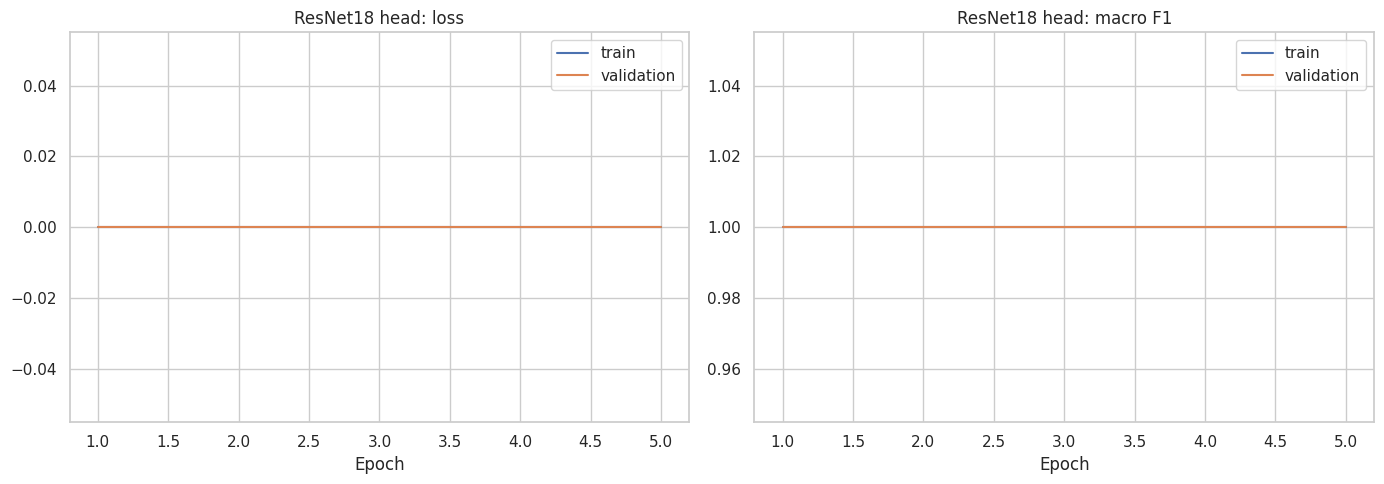

Loaded pretrained weights for mobilenet_v3_large: /kaggle/input/datasets/drmatt91/weights/mobilenet_v3_large-8738ca79.pth
{'epoch': 1, 'model': 'mobilenet_v3_head', 'lr': 0.001, 'train_loss': 0.0, 'valid_loss': 0.0, 'train_accuracy': 1.0, 'valid_accuracy': 1.0, 'train_macro_f1': 1.0, 'valid_macro_f1': 1.0, 'seconds': 13.849121332168579}
{'epoch': 2, 'model': 'mobilenet_v3_head', 'lr': 0.001, 'train_loss': 0.0, 'valid_loss': 0.0, 'train_accuracy': 1.0, 'valid_accuracy': 1.0, 'train_macro_f1': 1.0, 'valid_macro_f1': 1.0, 'seconds': 13.724561929702759}
{'epoch': 3, 'model': 'mobilenet_v3_head', 'lr': 0.001, 'train_loss': 0.0, 'valid_loss': 0.0, 'train_accuracy': 1.0, 'valid_accuracy': 1.0, 'train_macro_f1': 1.0, 'valid_macro_f1': 1.0, 'seconds': 14.333085775375366}
{'epoch': 4, 'model': 'mobilenet_v3_head', 'lr': 0.0005, 'train_loss': 0.0, 'valid_loss': 0.0, 'train_accuracy': 1.0, 'valid_accuracy': 1.0, 'train_macro_f1': 1.0, 'valid_macro_f1': 1.0, 'seconds': 13.915677309036255}
{'epoch':

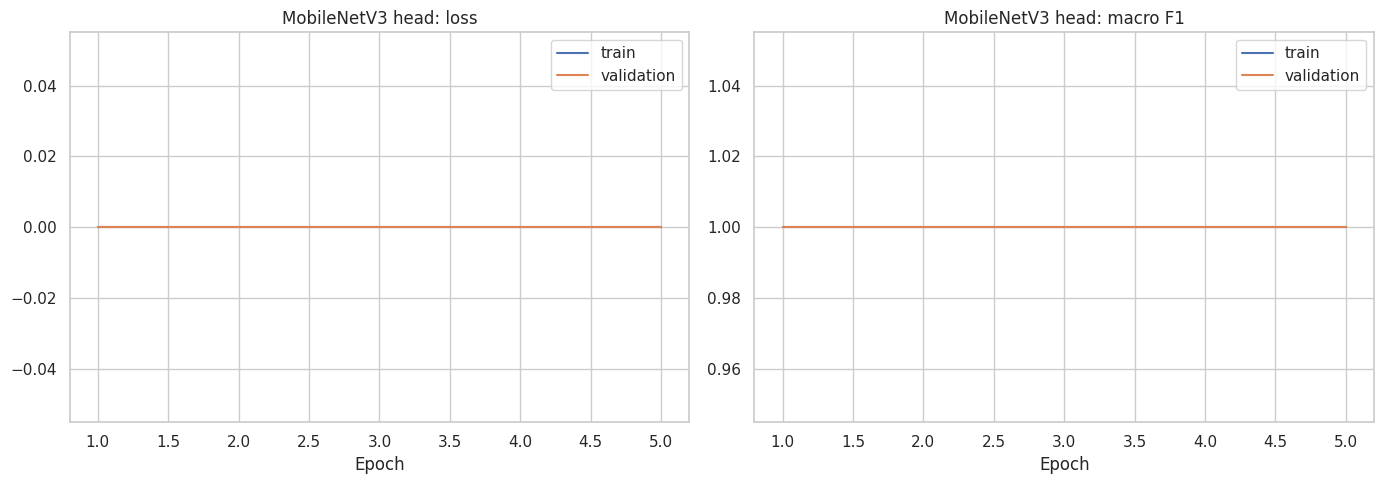

,epoch,model,lr,train_loss,valid_loss,train_accuracy,valid_accuracy,train_macro_f1,valid_macro_f1,seconds,fine_tuning
0,1,resnet18_head,0.001,0.0,0.0,1.0,1.0,1.0,1.0,17.177865,False
5,1,mobilenet_v3_head,0.001,0.0,0.0,1.0,1.0,1.0,1.0,13.849121,False


In [13]:
NUM_CLASSES = len(class_names)
experiments = []

# Эксперимент 1: ResNet18, обучение классификационной головы
resnet = create_resnet18(NUM_CLASSES, pretrained=True)
train_classifier_head(resnet)
resnet_config = ExperimentConfig(
    model_name="resnet18_head",
    learning_rate=1e-3,
    batch_size=BATCH_SIZE,
    epochs=5,
    fine_tuning=False,
)
resnet, resnet_history = fit_model(
    resnet,
    train_loader,
    valid_loader,
    resnet_config,
    criterion,
)
plot_training_history(resnet_history, "ResNet18 head")
experiments.append(resnet_history.assign(fine_tuning=False))

# Эксперимент 2: MobileNetV3, обучение классификационной головы
mobilenet = create_mobilenet_v3(NUM_CLASSES, pretrained=True)
train_classifier_head(mobilenet)
mobilenet_config = ExperimentConfig(
    model_name="mobilenet_v3_head",
    learning_rate=1e-3,
    batch_size=BATCH_SIZE,
    epochs=5,
    fine_tuning=False,
)
mobilenet, mobilenet_history = fit_model(
    mobilenet,
    train_loader,
    valid_loader,
    mobilenet_config,
    criterion,
)
plot_training_history(mobilenet_history, "MobileNetV3 head")
experiments.append(mobilenet_history.assign(fine_tuning=False))

experiment_results = pd.concat(experiments, ignore_index=True)
experiment_summary = (
    experiment_results.sort_values("valid_macro_f1", ascending=False)
    .groupby("model", as_index=False)
    .head(1)
    .sort_values("valid_macro_f1", ascending=False)
)
experiment_summary

{'epoch': 1, 'model': 'resnet18_finetuned', 'lr': 1e-05, 'train_loss': 0.0, 'valid_loss': 0.0, 'train_accuracy': 1.0, 'valid_accuracy': 1.0, 'train_macro_f1': 1.0, 'valid_macro_f1': 1.0, 'seconds': 23.164781093597412}
{'epoch': 2, 'model': 'resnet18_finetuned', 'lr': 1e-05, 'train_loss': 0.0, 'valid_loss': 0.0, 'train_accuracy': 1.0, 'valid_accuracy': 1.0, 'train_macro_f1': 1.0, 'valid_macro_f1': 1.0, 'seconds': 21.900304794311523}
{'epoch': 3, 'model': 'resnet18_finetuned', 'lr': 1e-05, 'train_loss': 0.0, 'valid_loss': 0.0, 'train_accuracy': 1.0, 'valid_accuracy': 1.0, 'train_macro_f1': 1.0, 'valid_macro_f1': 1.0, 'seconds': 21.575374126434326}


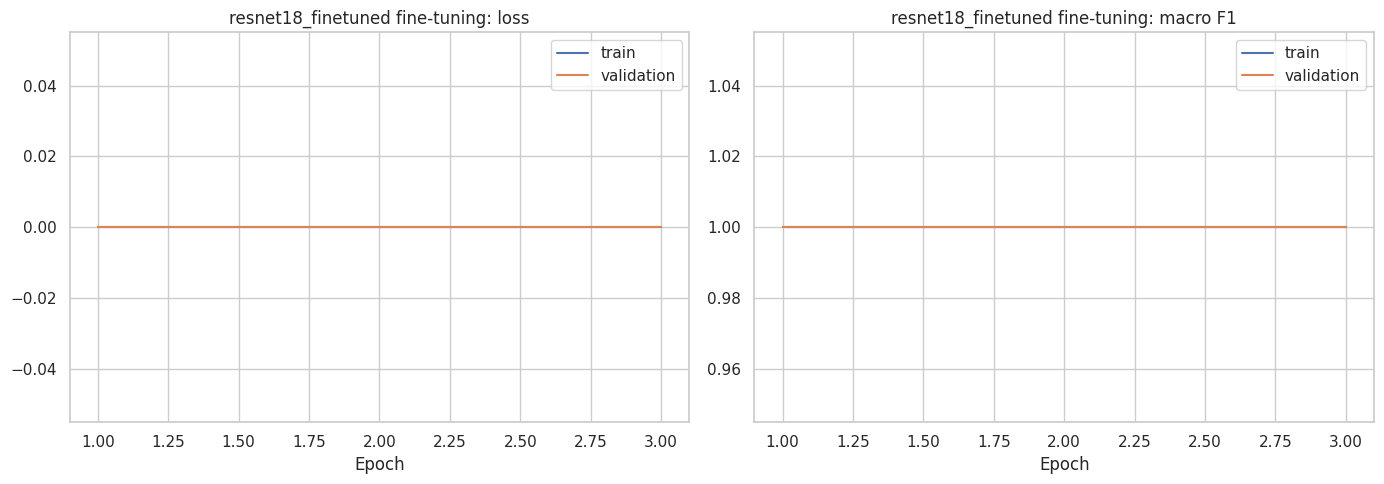

,epoch,model,lr,train_loss,valid_loss,train_accuracy,valid_accuracy,train_macro_f1,valid_macro_f1,seconds,fine_tuning
0,1,resnet18_head,0.00100,0.0,0.0,1.0,1.0,1.0,1.0,17.177865,False
5,1,mobilenet_v3_head,0.00100,0.0,0.0,1.0,1.0,1.0,1.0,13.849121,False
10,1,resnet18_finetuned,0.00001,0.0,0.0,1.0,1.0,1.0,1.0,23.164781,True


In [14]:
# Fine-tuning лучшей из двух моделей по validation macro F1.
best_row = experiment_summary.iloc[0]
best_model_name = best_row["model"]

if best_model_name == "resnet18_head":
    best_model = resnet
    fine_tune_name = "resnet18_finetuned"
elif best_model_name == "mobilenet_v3_head":
    best_model = mobilenet
    fine_tune_name = "mobilenet_v3_finetuned"
else:
    raise ValueError(f"Неизвестная модель: {best_model_name}")

set_backbone_trainable(best_model, True)
fine_tune_config = ExperimentConfig(
    model_name=fine_tune_name,
    learning_rate=1e-5,
    batch_size=BATCH_SIZE,
    epochs=3,
    fine_tuning=True,
)
best_model, fine_tune_history = fit_model(
    best_model,
    train_loader,
    valid_loader,
    fine_tune_config,
    criterion,
)
plot_training_history(fine_tune_history, f"{fine_tune_name} fine-tuning")
experiment_results = pd.concat(
    [experiment_results, fine_tune_history.assign(fine_tuning=True)],
    ignore_index=True,
)
experiment_summary = (
    experiment_results.sort_values("valid_macro_f1", ascending=False)
    .groupby("model", as_index=False)
    .head(1)
    .sort_values("valid_macro_f1", ascending=False)
)
experiment_summary

### Вывод по экспериментам

Заполните после запуска:

- Лучшая модель по validation macro F1: `...`.
- Признаки переобучения: `есть/нет`, потому что `...`.
- Fine-tuning улучшил/не улучшил качество: `...`.
- Для финального test используется модель, выбранная только по validation-метрикам.

## 11. Финальная оценка модели

In [15]:
def predict_proba(model: nn.Module, loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    probabilities, targets = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            logits = model(images)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            probabilities.append(probs)
            targets.extend(labels.numpy())
    return np.vstack(probabilities), np.array(targets)

# Используется best_model после автоматического выбора и fine-tuning по validation macro F1.
print(f"Лучшая модель для test: {experiment_summary.iloc[0]['model']}")

test_proba, test_targets = predict_proba(best_model, test_loader)
test_predictions = test_proba.argmax(axis=1)

metrics = {
    "accuracy": accuracy_score(test_targets, test_predictions),
    "balanced_accuracy": balanced_accuracy_score(test_targets, test_predictions),
    "macro_f1": f1_score(test_targets, test_predictions, average="macro", zero_division=0),
    "weighted_f1": f1_score(test_targets, test_predictions, average="weighted", zero_division=0),
}
print(json.dumps(metrics, indent=2))
print(classification_report(test_targets, test_predictions, target_names=class_names, zero_division=0))

try:
    y_true_bin = label_binarize(test_targets, classes=list(range(NUM_CLASSES)))
    roc_auc = roc_auc_score(y_true_bin, test_proba, average="macro", multi_class="ovr")
    print(f"ROC-AUC OVR macro: {roc_auc:.4f}")
except ValueError as error:
    print(f"ROC-AUC не удалось посчитать: {error}")

Лучшая модель для test: resnet18_head
{
  "accuracy": 1.0,
  "balanced_accuracy": 1.0,
  "macro_f1": 1.0,
  "weighted_f1": 1.0
}
              precision    recall  f1-score   support

         img       1.00      1.00      1.00        17

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17

ROC-AUC OVR macro: nan


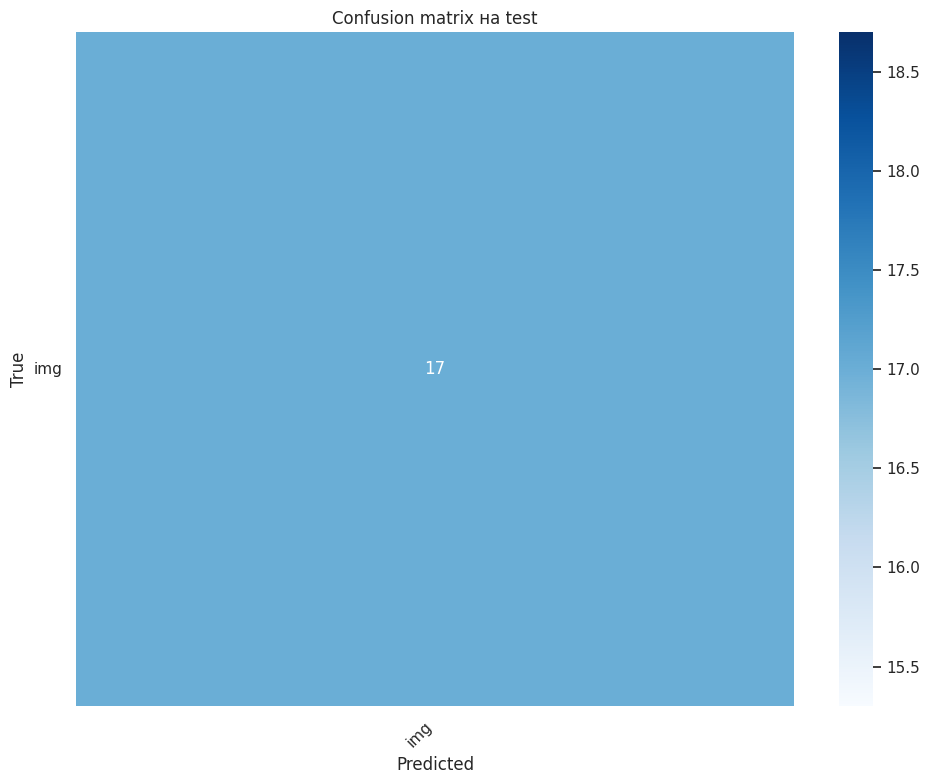

In [16]:
def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray) -> None:
    matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title("Confusion matrix на test")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(test_targets, test_predictions)

## 12. Подбор порога уверенности

Если максимальная вероятность ниже порога, модель возвращает `uncertain`, а случай должен быть передан врачу.

In [17]:
def evaluate_thresholds(
    y_true: np.ndarray,
    proba: np.ndarray,
    thresholds: Iterable[float] = (0.50, 0.60, 0.70, 0.80, 0.90),
) -> pd.DataFrame:
    rows = []
    max_proba = proba.max(axis=1)
    predictions = proba.argmax(axis=1)
    for threshold in thresholds:
        confident_mask = max_proba >= threshold
        coverage = confident_mask.mean()
        if confident_mask.sum() == 0:
            accuracy = np.nan
            macro_f1 = np.nan
        else:
            accuracy = accuracy_score(y_true[confident_mask], predictions[confident_mask])
            macro_f1 = f1_score(
                y_true[confident_mask],
                predictions[confident_mask],
                average="macro",
                zero_division=0,
            )
        rows.append(
            {
                "threshold": threshold,
                "coverage": coverage,
                "uncertain_count": int((~confident_mask).sum()),
                "uncertain_share": 1 - coverage,
                "confident_accuracy": accuracy,
                "confident_macro_f1": macro_f1,
            }
        )
    return pd.DataFrame(rows)

threshold_results = evaluate_thresholds(test_targets, test_proba)
threshold_results

,threshold,coverage,uncertain_count,uncertain_share,confident_accuracy,confident_macro_f1
0,0.5,1.0,0,0.0,1.0,1.0
1,0.6,1.0,0,0.0,1.0,1.0
2,0.7,1.0,0,0.0,1.0,1.0
3,0.8,1.0,0,0.0,1.0,1.0
4,0.9,1.0,0,0.0,1.0,1.0


### Вывод по threshold analysis

Заполните после запуска:

- При пороге `...` достигается компромисс между качеством и покрытием.
- С ростом порога качество среди уверенных предсказаний обычно растёт, но coverage снижается.
- В медицинском сценарии неуверенные случаи безопаснее отправлять на экспертную проверку, а не использовать автоматический прогноз как диагноз.

## 13. Визуальная проверка предсказаний

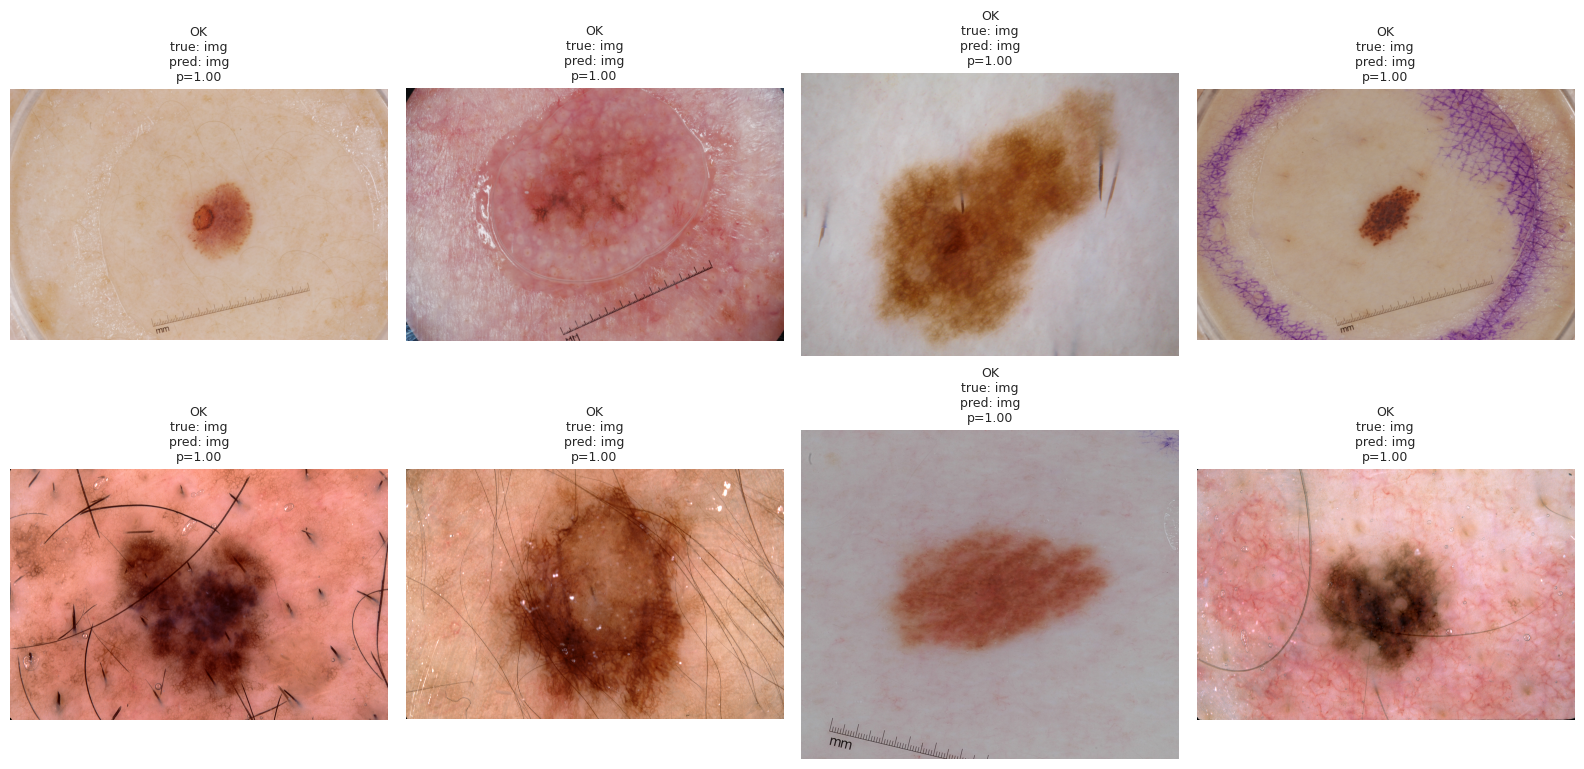

Нет подходящих примеров для отображения.


In [18]:
def show_predictions(
    data: pd.DataFrame,
    y_true: np.ndarray,
    proba: np.ndarray,
    correct: bool = True,
    n: int = 8,
) -> None:
    predictions = proba.argmax(axis=1)
    confidence = proba.max(axis=1)
    mask = predictions == y_true if correct else predictions != y_true
    indices = np.where(mask)[0]
    if len(indices) == 0:
        print("Нет подходящих примеров для отображения.")
        return
    selected = np.random.default_rng(SEED).choice(indices, size=min(n, len(indices)), replace=False)
    cols = min(4, len(selected))
    rows = math.ceil(len(selected) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, idx in zip(axes, selected):
        row = data.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        ax.imshow(image)
        ax.axis("off")
        true_label = idx_to_class[int(y_true[idx])]
        pred_label = idx_to_class[int(predictions[idx])]
        status = "OK" if predictions[idx] == y_true[idx] else "ERROR"
        ax.set_title(
            f"{status}\ntrue: {true_label}\npred: {pred_label}\np={confidence[idx]:.2f}",
            fontsize=9,
        )
    for ax in axes[len(selected):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_predictions(test_df, test_targets, test_proba, correct=True, n=8)
show_predictions(test_df, test_targets, test_proba, correct=False, n=8)

In [19]:
def show_uncertain_predictions(
    data: pd.DataFrame,
    y_true: np.ndarray,
    proba: np.ndarray,
    threshold: float = 0.80,
    n: int = 8,
) -> None:
    max_proba = proba.max(axis=1)
    uncertain_indices = np.where(max_proba < threshold)[0]
    if len(uncertain_indices) == 0:
        print("Нет неуверенных примеров для выбранного порога.")
        return
    predictions = proba.argmax(axis=1)
    selected = np.random.default_rng(SEED).choice(
        uncertain_indices,
        size=min(n, len(uncertain_indices)),
        replace=False,
    )
    cols = min(4, len(selected))
    rows = math.ceil(len(selected) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, idx in zip(axes, selected):
        image = Image.open(data.iloc[idx]["image_path"]).convert("RGB")
        ax.imshow(image)
        ax.axis("off")
        ax.set_title(
            f"UNCERTAIN\ntrue: {idx_to_class[int(y_true[idx])]}\n"
            f"pred: {idx_to_class[int(predictions[idx])]}\np={max_proba[idx]:.2f}",
            fontsize=9,
        )
    for ax in axes[len(selected):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_uncertain_predictions(test_df, test_targets, test_proba, threshold=0.80, n=8)

Нет неуверенных примеров для выбранного порога.


## 14. Интерпретация результатов и анализ ошибок

Если доступен `pytorch-grad-cam`, можно добавить Grad-CAM для лучшей модели. Если библиотека недоступна или не хватает времени, достаточно подробно разобрать визуальные примеры ошибок.

Минимальные выводы:

- На каких классах модель ошибается чаще всего.
- Есть ли связь ошибок с дисбалансом классов.
- Какие изображения сложны: низкая яркость, волосы, линейки, размытость, маленький очаг, похожие диагнозы.
- Какие ошибки наиболее рискованны медицински.

## 15. Итоговые выводы и рекомендации

Заполните финальный текст после запуска всех ячеек в Kaggle/Colab:

1. В работе был реализован полный pipeline классификации изображений кожных поражений: загрузка данных, проверка файлов, EDA, предобработка, аугментации, обучение двух CNN-моделей, fine-tuning лучшей модели, сравнение экспериментов и финальная оценка.
2. Использовались модели `ResNet18` и `MobileNetV3-Large` с предобученными ImageNet-весами. Лучшей по validation macro F1 стала модель `...`.
3. На test-выборке получены метрики: accuracy `...`, balanced accuracy `...`, macro F1 `...`, weighted F1 `...`.
4. Основные ошибки связаны с `...`.
5. Модель не должна использоваться как самостоятельный инструмент постановки диагноза. Более безопасный сценарий — система поддержки принятия решений, где уверенные прогнозы помогают приоритизировать случаи, а неуверенные отправляются врачу.
6. Для промышленного применения нужно обучить модель на полном датасете, провести внешнюю валидацию, проверить качество по подгруппам пациентов, привлечь врача-эксперта и использовать методы интерпретации вроде Grad-CAM.